# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Nguyễn Trần Quang"  # TODO: Họ và tên
STUDENT_ID = "2510209"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Trần Quang (2510209)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
    Path("/content/automobile_raw.csv")
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: /media/quangnguyen/DATA/mliot-pyml-2026-hw/week02/numpy-pandas-eda-hw/data/automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
max_logits = np.max(logits, axis=1, keepdims=True)
shifted_logits = logits - max_logits

exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

# --- In kết quả ra để kiểm tra ---
print("1. shifted_logits:\n", shifted_logits)
print("\n2. class_probabilities:\n", class_probabilities)
print("\n3. predicted_classes:\n", predicted_classes)
print("\n4. confidence_scores:\n", confidence_scores)

1. shifted_logits:
 [[ 0.  -1.  -1.9]
 [-1.   0.  -2. ]
 [-5.  -4.   0. ]
 [ 0.   0.   0. ]]

2. class_probabilities:
 [[0.65900114 0.24243297 0.09856589]
 [0.24472847 0.66524096 0.09003057]
 [0.00657326 0.01786798 0.97555875]
 [0.33333333 0.33333333 0.33333333]]

3. predicted_classes:
 [0 1 2 0]

4. confidence_scores:
 [0.65900114 0.66524096 0.97555875 0.33333333]


In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
train_feature_mean = X_train.mean(axis=0, keepdims=True)
train_feature_std = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - train_feature_mean)/train_feature_std
X_val_scaled = (X_val - train_feature_mean)/train_feature_std

# --- In kết quả để kiểm tra ---
print("train_feature_mean:\n", train_feature_mean)
print("\ntrain_feature_std:\n", train_feature_std)
print("\nX_train_scaled:\n", X_train_scaled)
print("\nX_val_scaled:\n", X_val_scaled)

train_feature_mean:
 [[172.5         69.16666667   1.65        28.16666667]]

train_feature_std:
 [[ 7.47774476 13.04372987  0.79109629  7.64671316]]

X_train_scaled:
 [[-0.3343254  -0.31943828 -0.56883088 -0.80644671]
 [ 1.0029762   0.83053953  0.94805147  0.89363014]
 [-1.671627   -1.4694161  -1.07445834 -1.19877214]
 [ 0.3343254   0.06388766 -0.18961029 -0.02179586]
 [-0.60178572 -0.70276422 -0.82164461 -0.54489643]
 [ 1.27043652  1.59719141  1.70649265  1.67828099]]

X_val_scaled:
 [[-0.06686508 -0.08944272 -0.31601716 -0.28334614]
 [ 2.34027779  1.98051735  2.21212011  2.20138156]]


In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
correct_mask = (predicted_classes == true_labels)
high_confidence_mask = (confidence_scores >= confidence_threshold)
review_mask = ~correct_mask | ~high_confidence_mask
review_indices = np.where(review_mask)[0]

# --- In kết quả để kiểm tra ---
print("correct_mask:\n", correct_mask)
print("high_confidence_mask:\n", high_confidence_mask)
print("review_mask:\n", review_mask)
print("review_indices:\n", review_indices)

correct_mask:
 [ True False  True False]
high_confidence_mask:
 [False False  True False]
review_mask:
 [ True  True False  True]
review_indices:
 [0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = normalized_batch[:,:,::-1,:].copy()
augmented_batch[0, 0, 0, 0] = 1.0

# --- In shape và kiểm tra để chắc chắn bộ nhớ đã độc lập ---
print("Giá trị tại normalized_batch[0, 0, -1, 0]:", normalized_batch[0, 0, -1, 0])
print("Giá trị tại augmented_batch[0, 0, 0, 0]:", augmented_batch[0, 0, 0, 0])

Giá trị tại normalized_batch[0, 0, -1, 0]: 0.03529412
Giá trị tại augmented_batch[0, 0, 0, 0]: 1.0


# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.

2. Giá trị thiếu (missing value) trong tệp CSV được giữ dưới dạng ký hiệu '?'.

3. Thuộc tính symboling có ý nghĩa là mức đánh giá rủi ro bảo hiểm.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1

raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()

display(raw_df.head())
print(raw_shape)
print(raw_missing_marker_count)

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


(205, 26)
59


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isna().sum()

display(df_clean.head())
print(missing_by_column)

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?

Mỗi cột có thang đo và ý nghĩa thực tế riêng biệt(ví dụ: curb_weight tính bằng pounds, trong khi city_mpg tính bằng miles per gallon). Việc điền chung một giá trị sẽ làm phá vỡ phân phối và mối tương quan của dữ liệu.

- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?

Nên drop (xóa dòng). Vì price là biến mục tiêu quan trọng và chỉ thiếu 4 dòng, việc xóa sẽ giữ được tính chân thực của dữ liệu mà không làm hao hụt đáng kể kích thước tập mẫu.

- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

Cột này thiếu tới 41 giá trị. Nếu xóa dòng sẽ làm mất một lượng lớn thông tin từ các cột khác, nhưng nếu điền khuyết đơn giản (như trung bình/trung vị) sẽ làm giảm phương sai một cách giả tạo và gây nhiễu phân phối.

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

Chất lượng của tập dữ liệu thô không đồng đều, đòi hỏi chiến lược xử lý Missing Value linh hoạt theo từng đặc thù của cột. Không có một phương pháp (drop hay fill) nào hoàn hảo cho toàn bộ tập dữ liệu; thay vào đó, cần ưu tiên bảo vệ tính nguyên bản của biến mục tiêu (price) và cẩn trọng với các biến có tỷ lệ khuyết thiếu cao (normalized_losses) để tránh đưa ra các sai lệch trong bước phân tích EDA tiếp theo.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
# Lấy 6 cột từ AUTO_FEATURES và drop các dòng có giá trị thiếu
analysis_df = df_clean[AUTO_FEATURES].dropna()

# Lấy 6 cột từ AUTO_FEATURES và drop các dòng có giá trị thiếu
X_auto = analysis_df.to_numpy(dtype='float64')

auto_feature_mean = X_auto.mean(axis=0) # or np.mean(X_auto, axis=0)
auto_feature_std = X_auto.std(axis=0)   # or np.std(X_auto, axis=0)
X_auto_scaled = (X_auto - auto_feature_mean)/ auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
# Tìm vị trí (index) của cột 'price' trong danh sách AUTO_FEATURES
price_index = AUTO_FEATURES.index('price')

price_z = X_auto_scaled[:, price_index]
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df[price_outlier_mask]

display(X_auto_scaled[price_outlier_mask][:, price_index])
price_outliers

array([2.20095117, 3.52718357, 2.96992723, 2.3881692 , 2.80281315,
       2.85935551, 2.30649691, 2.63117569, 2.74074221, 3.48257793,
       4.04046252, 2.42309981, 2.61157434, 2.98852338])

,curb_weight,engine_size,horsepower,city_mpg,highway_mpg,price
15,3230,209,182.0,16,22,30760.0
16,3380,209,182.0,16,22,41315.0
17,3505,209,182.0,15,20,36880.0
47,4066,258,176.0,15,19,32250.0
48,4066,258,176.0,15,19,35550.0
49,3950,326,262.0,13,17,36000.0
70,3770,183,123.0,22,25,31600.0
71,3740,234,155.0,16,18,34184.0
72,3685,234,155.0,16,18,35056.0
73,3900,308,184.0,14,16,40960.0


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5

engine_index = AUTO_FEATURES.index('engine_size')
engine_price_corr = np.corrcoef(X_auto[:, engine_index], X_auto[:, price_index])[0, 1]

# np.corrcoef(...): Hàm của thư viện NumPy dùng để tính toán ma trận tương quan Pearson
# (một ma trận 2x2) giữa hai mảng dữ liệu này.
# [0, 1]: Trích xuất phần tử ở hàng 0, cột 1 của ma trận.

price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

display(engine_price_corr.round(2))
display(price_by_body_style)

np.float64(0.87)

body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

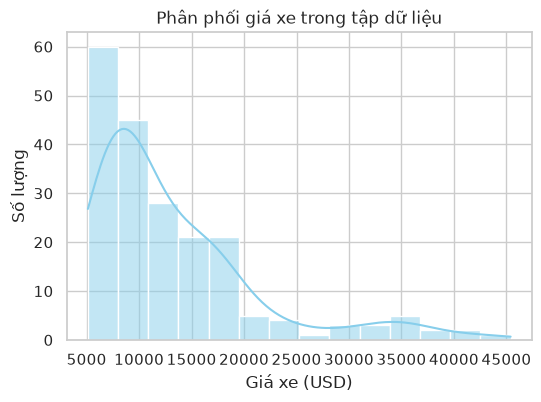

In [20]:
# TODO M2.1: histogram/KDE của price
fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(data=df_clean, x='price', kde=True, color="skyblue", ax=ax)
ax.set_title('Phân phối giá xe trong tập dữ liệu')
ax.set_xlabel('Giá xe (USD)')
ax.set_ylabel('Số lượng')
plt.show()

# plt.figure(figsize=(6,4))
# sns.histplot(data=df_clean, x='price', kde=True, color='skyblue')
# plt.title('Phân phối giá xe trong tập dữ liệu')
# plt.xlabel('Giá xe (USD)')
# plt.ylabel('Số lượng')
# plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Phân phối giá xe có dạng lệch phải, tập trung chủ yếu ở phân khúc giá thấp từ 5000 đến 15000 USD. Có một số ít các mẫu xe đắt tiền tạo thành đuôi dài về phía bên phải của biểu đồ.

## M2.2 Dataset có cân bằng theo body style không?

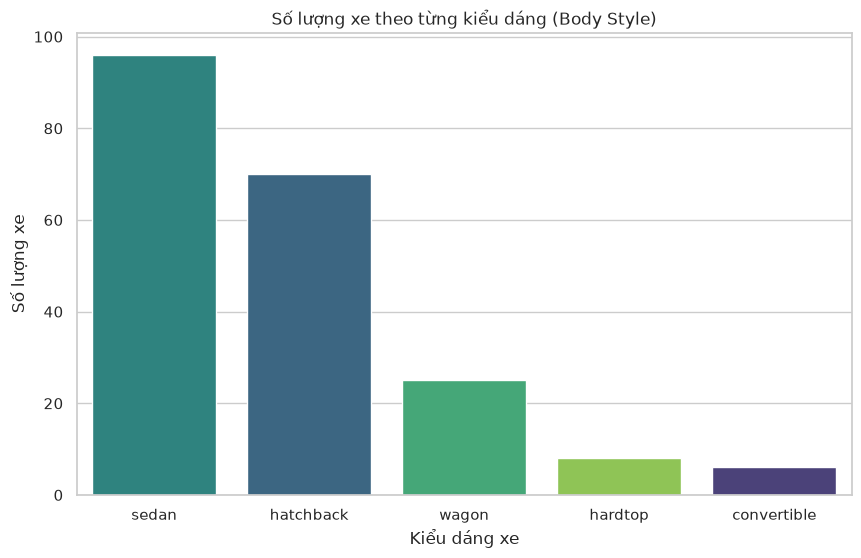

In [21]:
# TODO M2.2: countplot của body_style

# Sử dụng order để sắp xếp các cột từ cao xuống thấp cho dễ nhìn
fig, ax = plt.subplots(figsize=(10,6))
sns.countplot(data=df_clean, x='body_style', palette='viridis', ax=ax, order=df_clean['body_style'].value_counts().index,
              hue='body_style',
              legend=False,
)

ax.set_title('Số lượng xe theo từng kiểu dáng (Body Style)')
ax.set_xlabel('Kiểu dáng xe')
ax.set_ylabel('Số lượng xe')
plt.show()

# plt.figure(figsize=(10,6))
# sns.countplot(data=df_clean, x='body_style', order=df_clean['body_style'].value_counts().index, palette='viridis',
#     hue='body_style',  # Gán biến x vào hue
#     legend=False,      # Ẩn chú thích (legend)
# )
# plt.title('Số lượng xe theo từng kiểu dáng (Body Style)')
# plt.xlabel('Kiểu dáng xe')
# plt.ylabel('Số lượng xe')
# plt.show()


**Nhận xét:** <!-- 1--2 câu -->

Tập dữ liệu không cân bằng theo kiểu dáng xe; kiểu dáng sedan chiếm đa số áp đảo. Ngược lại, các kiểu dáng như convertible và hardtop có số lượng mẫu rất ít, điều này có thể ảnh hưởng đến khả năng dự đoán của mô hình trên các nhóm thiểu số này.

## M2.3 Price khác nhau theo body style ra sao?

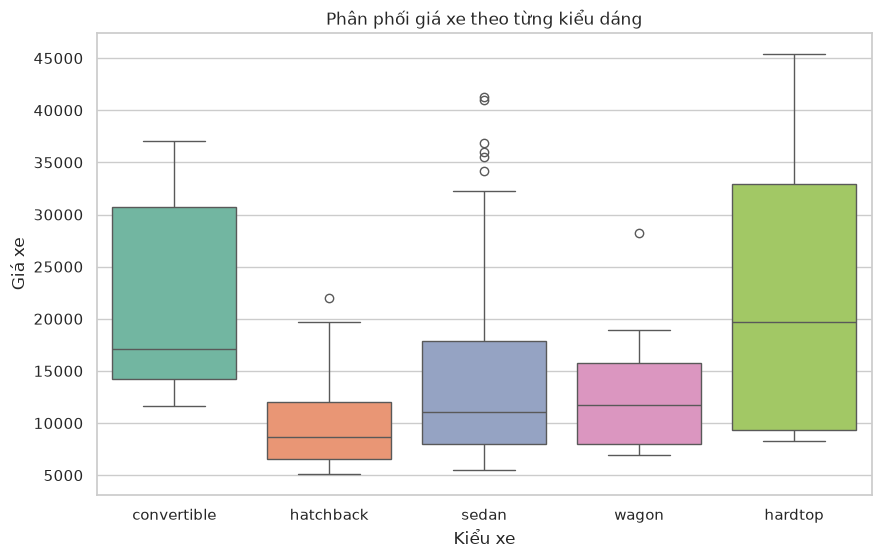

In [22]:
# TODO M2.3: boxplot price theo body_style
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(data=df_clean, x='body_style', y='price', ax=ax,
            palette='Set2',
            hue='body_style',
            legend=False
)
ax.set_title('Phân phối giá xe theo từng kiểu dáng')
ax.set_xlabel('Kiểu xe')
ax.set_ylabel('Giá xe')
plt.show()

# plt.figure(figsize=(10,6))
# sns.boxplot(data=df_clean, x='body_style', y='price', hue='body_style', legend=False, palette='Set2')
# plt.title('Phân phối giá xe theo từng kiểu dáng')
# plt.xlabel('Kiểu xe')
# plt.ylabel('Giá xe')
# plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Kiểu dáng hardtop/convertible có mức giá trung vị cao nhất và khoảng biến thiên giá rất rộng. Trong khi đó, các xe kiểu hatchback có mức giá thấp và tập trung hơn, mặc dù có xuất hiện một vài điểm dữ liệu ngoại lệ (outliers) có giá cao bất thường.

## M2.4 Engine size liên quan thế nào tới price?

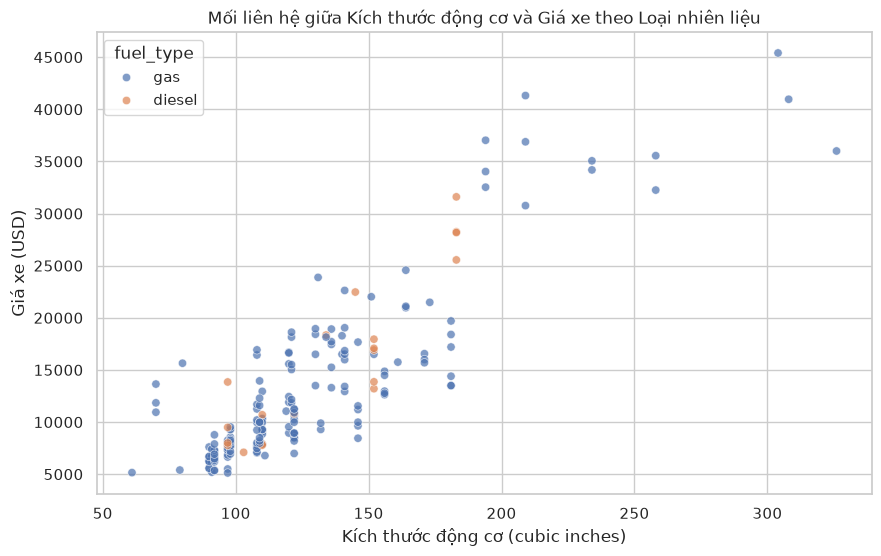

In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
fig, ax = plt.subplots(figsize=(10,6))

sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', alpha=0.7, ax=ax)
ax.set_title('Mối liên hệ giữa Kích thước động cơ và Giá xe theo Loại nhiên liệu')
ax.set_xlabel('Kích thước động cơ (cubic inches)')
ax.set_ylabel('Giá xe (USD)')
plt.show()

# plt.figure(figsize=(10,6))
# sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', alpha=0.7)
# plt.title('Mối liên hệ giữa Kích thước động cơ và Giá xe theo Loại nhiên liệu')
# plt.xlabel('Kích thước động cơ (cubic inches)')
# plt.ylabel('Giá xe (USD)')
# plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Biểu đồ cho thấy mối tương quan thuận khá rõ ràng: kích thước động cơ càng lớn thì giá xe có xu hướng càng cao. Các xe sử dụng nhiên liệu diesel dường như tập trung ở một số dải kích thước động cơ nhất định so với xe xăng (gas).

## M2.5 Các feature numeric tương quan ra sao?

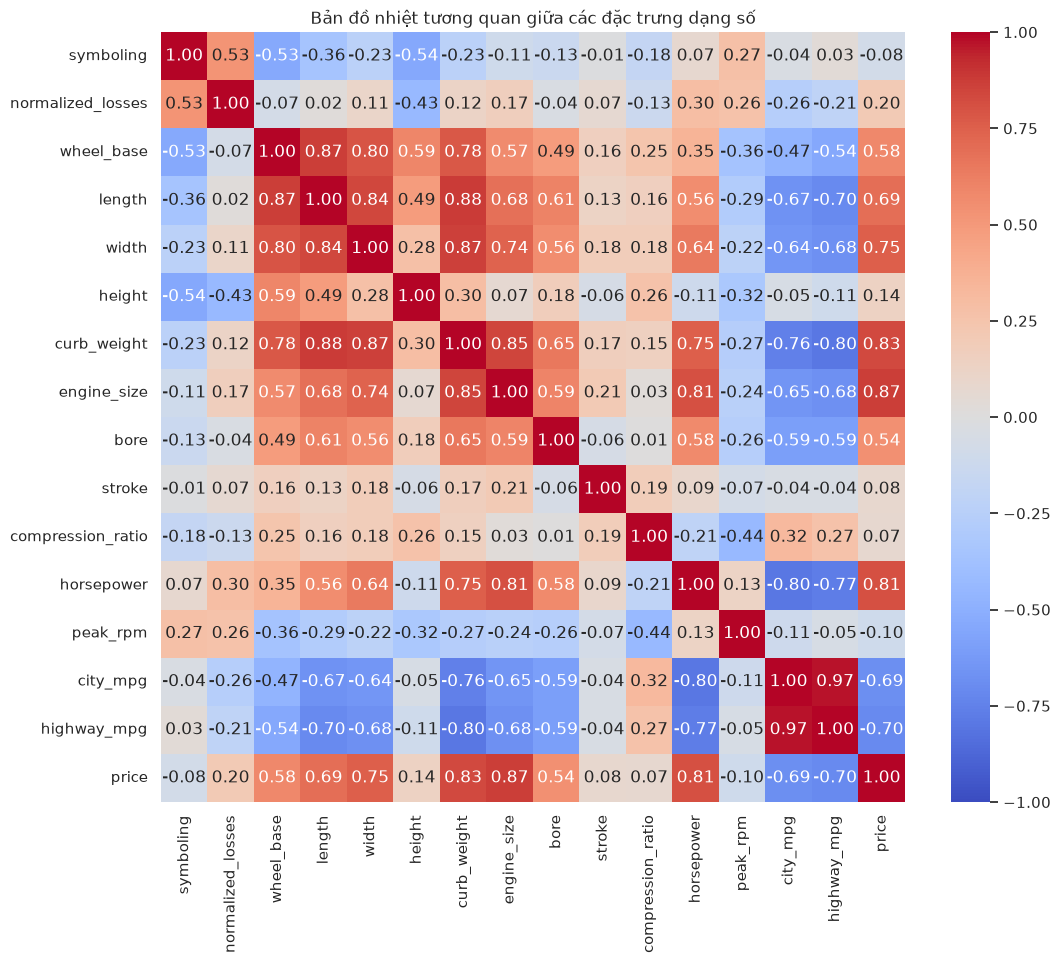

In [24]:
# TODO M2.5: correlation heatmap
fig, ax = plt.subplots(figsize=(12,10))

# Lọc riêng các cột dạng số để tính toán tương quan
numeric_df = df_clean.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
# display(corr_matrix)
sns.heatmap(
    data=corr_matrix,
    annot=True,       # Hiển thị số liệu trên từng ô
    cmap='coolwarm',  # Dải màu từ lạnh (âm) sang nóng (dương)
    fmt=".2f",
    vmin=-1, vmax=1,
    ax=ax,
)
ax.set_title('Bản đồ nhiệt tương quan giữa các đặc trưng dạng số')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Giá xe (price) có độ tương quan dương mạnh nhất với các đặc trưng như engine_size, curb_weight, và horsepower. Ngược lại, nó có tương quan âm khá rõ với mức độ tiết kiệm nhiên liệu (city_mpg và highway_mpg), nghĩa là xe càng đắt tiền thì thường tiêu tốn nhiều nhiên liệu hơn.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

Barplot. Câu hỏi: "Hệ dẫn động (drive-wheels) ảnh hưởng thế nào đến giá xe trung bình?"

(Barplot khác với Countplot ở chỗ nó thường dùng để vẽ giá trị trung bình/tổng của một biến số theo một biến phân loại, thay vì chỉ đếm số lượng).

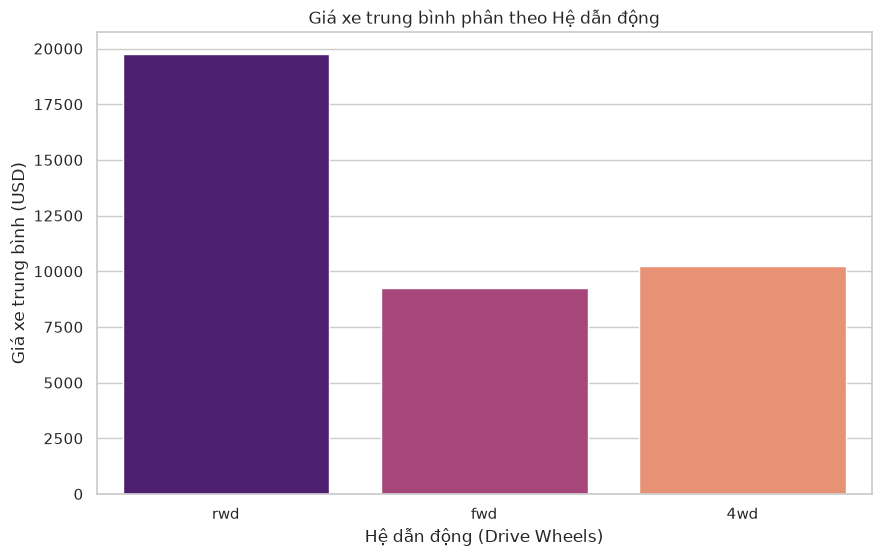

In [25]:
# TODO M2.6: biểu đồ tự chọn
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(data=df_clean, x='drive_wheels', y='price', hue='drive_wheels', palette='magma', legend=False, ax=ax, errorbar=None,)        # Ẩn thanh sai số cho biểu đồ gọn gàng
ax.set_title('Giá xe trung bình phân theo Hệ dẫn động')
ax.set_xlabel('Hệ dẫn động (Drive Wheels)')
ax.set_ylabel('Giá xe trung bình (USD)')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Dựa vào biểu đồ, xe có hệ dẫn động cầu sau (rwd - rear wheel drive) có mức giá trung bình cao nhất, vượt trội hơn hẳn so với hệ dẫn động cầu trước (fwd) và dẫn động 4 bánh (4wd).

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

1. 3-5 Phát hiện chính (Key Insights) có dẫn chứng

Giá xe tập trung chủ yếu ở phân khúc bình dân: Dựa vào biểu đồ Histogram/KDE (M2.1), phân phối của price lệch phải (right-skewed) rõ rệt. Đa số các mẫu xe trong tập dữ liệu có giá dao động dưới 15.000 USD, trong khi xe hạng sang (trên 30.000 USD) chiếm tỷ lệ rất nhỏ.

Kích thước động cơ tỷ lệ thuận với giá xe: Cả biểu đồ Scatterplot (M2.4) và Correlation Heatmap (M2.5) đều cho thấy mối tương quan dương rất mạnh giữa engine_size và price. Kích thước động cơ càng lớn, giá xe có xu hướng càng cao.

Kiểu dáng và hệ dẫn động có ảnh hưởng rõ rệt tới giá trị xe: Thông qua Boxplot (M2.3) và Barplot (M2.6), ta thấy các dòng xe thể thao/mui trần (hardtop, convertible) hoặc sử dụng hệ dẫn động cầu sau (rwd) có mức giá trung bình và mức định giá tối đa vượt trội hơn hẳn so với các dòng xe phổ thông như hatchback hay xe dẫn động cầu trước (fwd).

2. Hai hạn chế của Dataset

Dữ liệu mất cân bằng (Imbalanced Data): Như quan sát tại biểu đồ Countplot (M2.2), số lượng xe phân bổ không đều theo body_style (sedan và hatchback chiếm đa số áp đảo). Điều này làm cho các suy luận thống kê hoặc mô hình học máy trên các nhóm thiểu số (như convertible) bị thiếu độ tin cậy do cỡ mẫu (sample size) quá nhỏ.

Kích thước tập dữ liệu nhỏ và có thể đã lỗi thời: Dataset này tương đối nhỏ (chỉ khoảng hơn 200 mẫu) và thiếu các đặc trưng quan trọng của thị trường ô tô hiện đại (như xe điện, xe hybrid, hệ thống an toàn thông minh). Ngoài ra, dữ liệu chứa khá nhiều giá trị khuyết thiếu (missing values) ở các cột quan trọng, buộc ta phải loại bỏ hoặc điền khống, làm giảm tính khách quan.

3. Ví dụ về "Correlation không đồng nghĩa Causation"

Ví dụ: Dựa vào Heatmap (M2.5), ta thấy chỉ số tiết kiệm nhiên liệu (city_mpg hoặc highway_mpg) có tương quan âm rất mạnh với giá xe (price) — tức là xe càng "tốn xăng" thì giá lại càng cao.

Giải thích: Tuy nhiên, việc "tốn xăng" (mpg thấp) tuyệt đối không phải là nguyên nhân (causation) làm cho chiếc xe trở nên đắt tiền. Yếu tố thực sự (biến ẩn - confounding variable) ở đây là trọng lượng xe (curb_weight) và sức mạnh động cơ (engine_size / horsepower). Những chiếc xe đắt tiền thường là xe sang, xe thể thao to nặng và sở hữu động cơ lớn. Việc tiêu hao nhiều nhiên liệu chỉ là hệ quả tất yếu đi kèm của khối động cơ lớn đó, chứ không phải là lý do để nhà sản xuất tăng giá bán.

4. Một câu hỏi nên phân tích tiếp

Câu hỏi đề xuất: "Thương hiệu xe (make) đóng góp bao nhiêu phần trăm vào việc quyết định giá bán?

 Liệu hai chiếc xe có cùng thông số kỹ thuật (mã lực, kích thước, hệ dẫn động) nhưng khác thương hiệu (một bình dân, một hạng sang) thì mức giá chênh lệch có hoàn toàn đến từ 'giá trị thương hiệu' hay không?"

 Phân tích này sẽ giúp ta hiểu rõ hơn về mức độ định giá cảm tính so với giá trị thực tế của vật liệu và kỹ thuật.